====== 데이터 정보 ======
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    object 
 3   smoker      244 non-null    object 
 4   day         244 non-null    object 
 5   time        244 non-null    object 
 6   size        244 non-null    int64  
dtypes: float64(2), int64(1), object(4)
memory usage: 13.5+ KB
None
       total_bill         tip        size
count  244.000000  244.000000  244.000000
mean    19.785943    2.998279    2.569672
std      8.902412    1.383638    0.951100
min      3.070000    1.000000    1.000000
25%     13.347500    2.000000    2.000000
50%     17.795000    2.900000    2.000000
75%     24.127500    3.562500    3.000000
max     50.810000   10.000000    6.000000


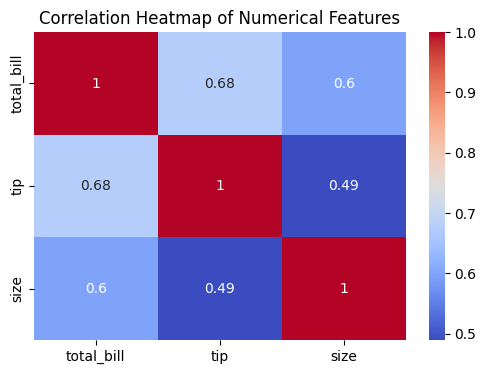

R2 Score: 0.2299
RMSE: 0.9811


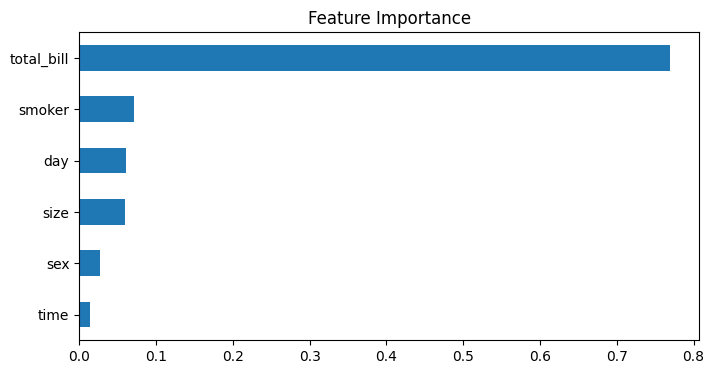

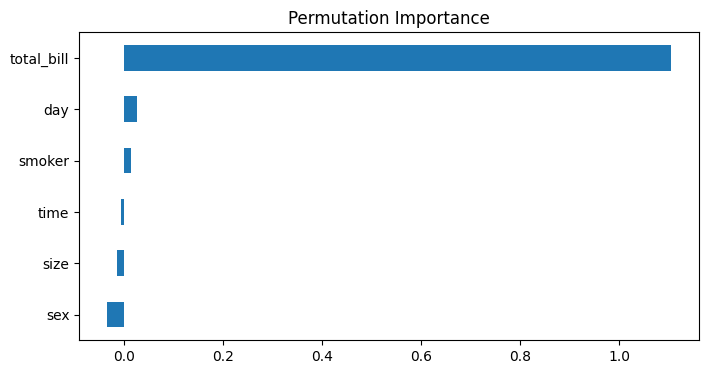

모델 저장 완료


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

from sklearn.inspection import permutation_importance
import joblib

# 1. 데이터 로드
df = pd.read_csv('dataset/tips.csv')

print('====== 데이터 정보 ======')
print(df.info())
print(df.describe())

# 2. EDA - 수치형 히트맵
plt.figure(figsize=(6, 4))
corr = df[['total_bill', 'tip', 'size']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

# 3. 라벨 인코딩
categorical_cols = ['sex', 'smoker', 'day', 'time']
encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

# 4. Feature / Target 분리
X = df.drop('tip', axis=1)
y = df['tip']

# 5. 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 6. 모델 학습
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 7. 예측
y_pred = model.predict(X_test)

# 8. 성능 평가
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f'R2 Score: {r2:.4f}')
print(f'RMSE: {rmse:.4f}')


# 9. Feature Importance
importances = pd.Series(model.feature_importances_, index=X.columns)

plt.figure(figsize=(8,4))
importances.sort_values().plot(kind='barh')
plt.title('Feature Importance')
plt.show()

# 10. Permutation Importance
perm = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42)

perm_importance = pd.Series(perm.importances_mean, index=X.columns)

plt.figure(figsize=(8,4))
perm_importance.sort_values().plot(kind='barh')
plt.title('Permutation Importance')
plt.show()

# 11. 모델 저장
joblib.dump(model, "model/tips_model01.pkl")
joblib.dump(encoders, 'model/tips_labelencoders01.pkl')
print("모델 저장 완료")

==== 데이터 정보 ====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    object 
 3   smoker      244 non-null    object 
 4   day         244 non-null    object 
 5   time        244 non-null    object 
 6   size        244 non-null    int64  
dtypes: float64(2), int64(1), object(4)
memory usage: 13.5+ KB
None


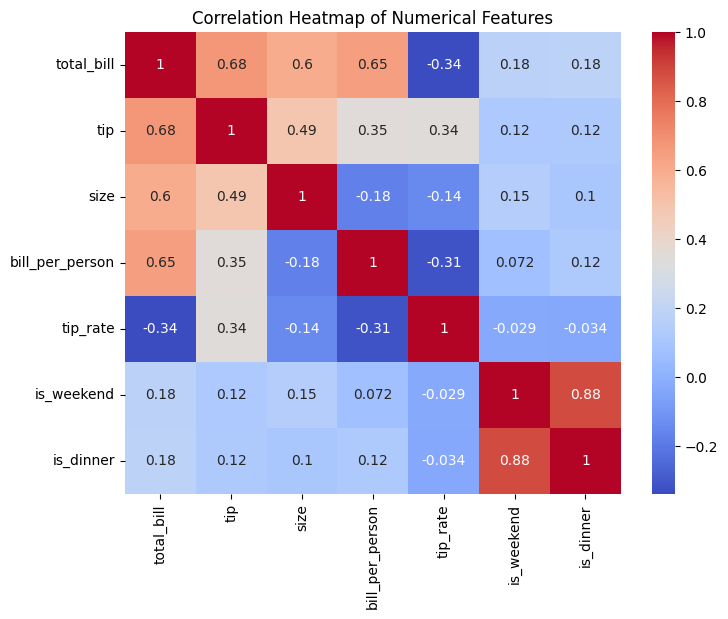

===== 모델 성능 =====
R2 Score: 0.8222
RMSE: 0.4714


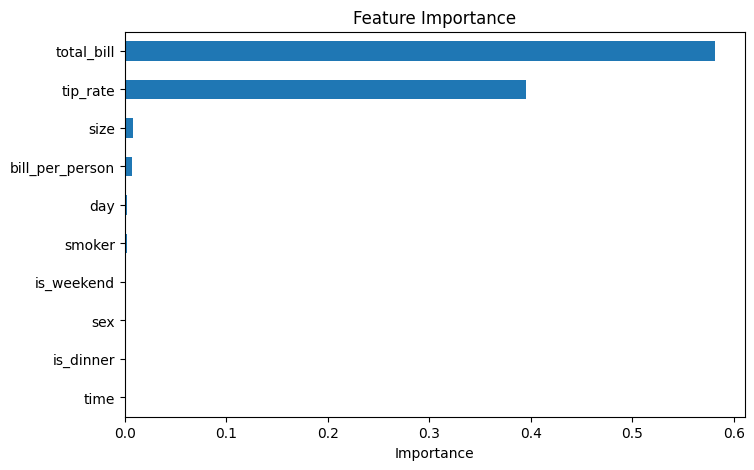

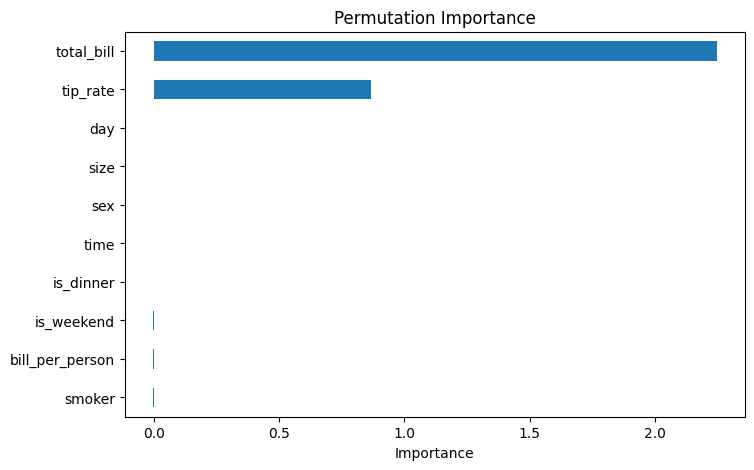

모델 저장 완료


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.inspection import permutation_importance

import joblib

# 1. 데이터 로드
df = pd.read_csv('dataset/tips.csv')

print('==== 데이터 정보 ====')
print(df.info())

# 2. Feature Engineering (추가된 피처, 파생변수 : 기존에 없던 정보를 새로 만들어 모델 성능을 높이는 작업)
df['bill_per_person'] = df['total_bill'] / df['size'] # 1인당 금액
df['is_weekend'] = df['day'].isin(['Sat', 'Sun']).astype(int) # 주말 여부
df['is_dinner'] = (df['time'] == 'Dinner').astype(int) # 저녁 여부
df['tip_rate'] = df['tip'] / df['total_bill'] # 팁 비율

# 3. 히트맵 분석 (수치형 + 파생변수 포함)
plt.figure(figsize=(8, 6))

numeric_cols = [
    'total_bill', 'tip', 'size',
    'bill_per_person', 'tip_rate',
    'is_weekend', 'is_dinner'
]

corr = df[numeric_cols].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

# 4. 라벨 인코딩
categorical_cols = ['sex', 'smoker', 'day', 'time']
encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

# 5. Feature / Target X, y 분리
X = df.drop('tip', axis=1)
y = df['tip']

# 6. 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 7. 모델 학습
model = RandomForestRegressor(
    n_estimators=500,
    random_state=42,
    max_depth=10,
    min_samples_leaf=3
    )
model.fit(X_train, y_train)

# 8. 예측 및 평가
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("===== 모델 성능 =====")
print(f"R2 Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")


# 9. Feature Importance
importances = pd.Series(model.feature_importances_, index=X.columns)

plt.figure(figsize=(8, 5))
importances.sort_values().plot(kind='barh')
plt.title('Feature Importance')
plt.xlabel('Importance')
plt.show()


# 10. Permutation Importance
perm = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42)

perm_importance = pd.Series(perm.importances_mean, index=X.columns)

plt.figure(figsize=(8, 5))
perm_importance.sort_values().plot(kind='barh')
plt.title('Permutation Importance')
plt.xlabel('Importance')
plt.show()

# 11. 모델 저장
joblib.dump(model, "model/tips_model02.pkl")
joblib.dump(encoders, 'model/tips_labelencoders02.pkl')
print("모델 저장 완료")


모델 성능 평가 : 
교차 검증 점수 : 
평균 정확도 : 0.7657 (+/- 0.0715)
분류 리포트
              precision    recall  f1-score   support

           0       0.79      0.79      0.79        99
           1       0.62      0.62      0.62        55

    accuracy                           0.73       154
   macro avg       0.70      0.70      0.70       154
weighted avg       0.73      0.73      0.73       154



d:\python_sim\venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 53945 (\N{HANGUL SYLLABLE TEUG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\python_sim\venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\python_sim\venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\python_sim\venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50836 (\N{HANGUL SYLLABLE YO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\python_sim\venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


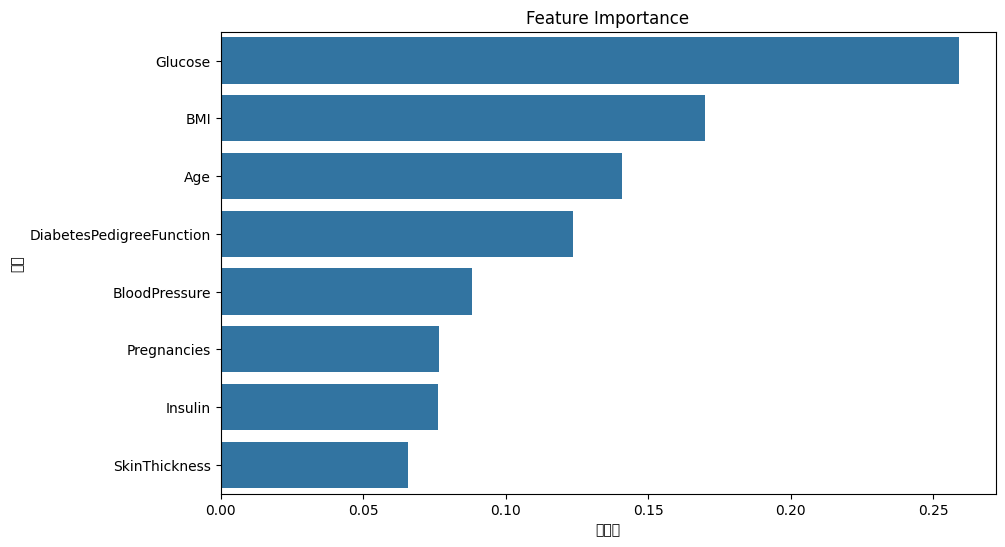

d:\python_sim\venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\python_sim\venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\python_sim\venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44050 (\N{HANGUL SYLLABLE GABS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\python_sim\venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\python_sim\venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


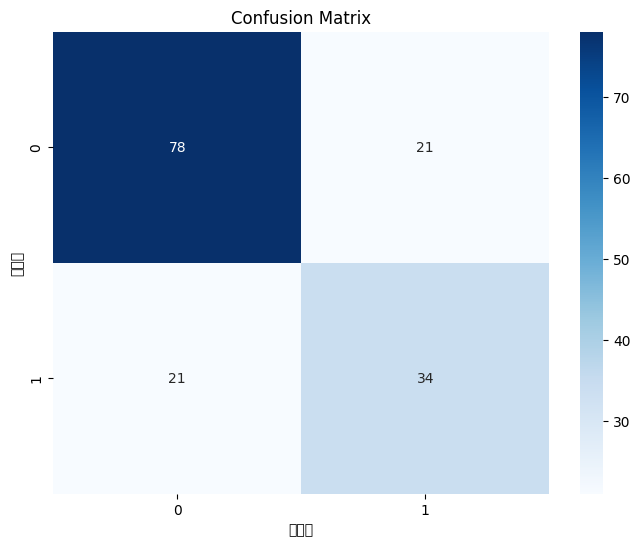

새로운 환자 데이터 예측 예시
예측 결과: 정상
당뇨병일 확률: 31.00%
예측 신뢰도 분석


d:\python_sim\venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48712 (\N{HANGUL SYLLABLE BIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\python_sim\venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\python_sim\venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49888 (\N{HANGUL SYLLABLE SIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\python_sim\venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47280 (\N{HANGUL SYLLABLE ROE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


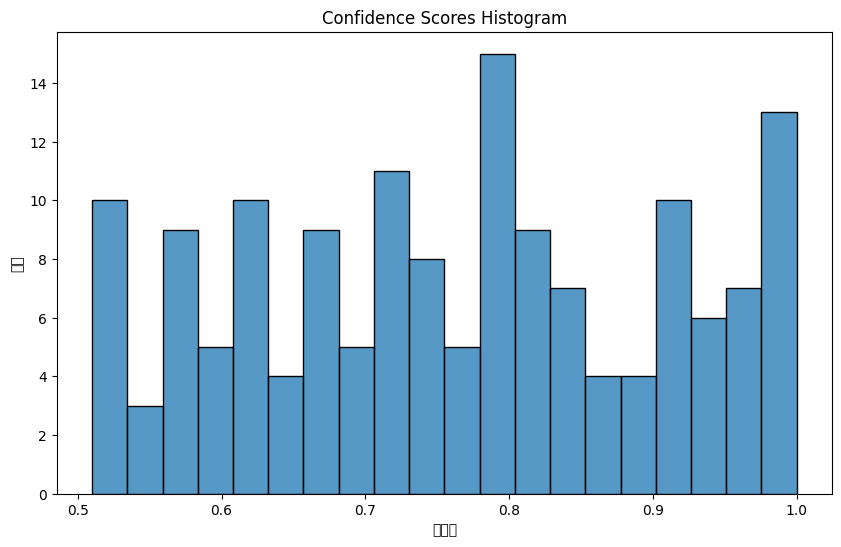

In [20]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score   # cross_val_score:파라미터를 사전 지정해서 교차검증
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 데이터 로드
data = pd.read_csv('dataset/diabetes.csv')

# 2. 특성과 타겟 분리
X = data.drop('Outcome', axis=1) # cf. 특정 피처만 선별할 때 : X = data[['bmi','Glucose','Age']]
y = data['Outcome']

# 3. 데이터 전치리 : 특성 스케일링
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# 4. 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 5. 랜덤 포레스트 모델 생성 및 학습
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf_model.fit(X_train, y_train)

# 6. 예측
y_pred = rf_model.predict(X_test)

# 7. 교차 검증 수행
cv_scores = cross_val_score(rf_model, X_scaled, y, cv=5)

# 8. 특성 중요도 계산 
feature_importance = pd.DataFrame({
    '특성' : X.columns,
    '중요도' : rf_model.feature_importances_
}).sort_values(by='중요도', ascending=False)

# 9. 결과 출력
print('모델 성능 평가 : ')
print('교차 검증 점수 : ')
print(f'평균 정확도 : {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})')
print('분류 리포트')
print(classification_report(y_test, y_pred)
)
# 10. 특성 중요도 시각화
plt.figure(figsize=(10, 6))
sns.barplot(x='중요도', y='특성', data=feature_importance)
plt.title('Feature Importance')
plt.show()

# 11. 혼동 행렬 시각화
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('실제값')
plt.ylabel('예측값')
plt.show()

# 12. 새로운 환자 데이터 예측 에시
print('새로운 환자 데이터 예측 예시')
# 임의의 환자 데이터 생성
new_patient = X_test.iloc[0:1] # 첫번째 인덱스 값
prediction = rf_model.predict(new_patient)
prediction_prob = rf_model.predict_proba(new_patient)

print(f"예측 결과: {'당뇨병 환자' if prediction[0] == 1 else '정상'}")
print(f"당뇨병일 확률: {prediction_prob[0][1]:.2%}")   # 첫번째 샘플의 두번째 클래스

# 13. 예측 신뢰도 분석
threshold_probs = rf_model.predict_proba(X_test)
confidence_scores = np.max(threshold_probs, axis=1)

print('예측 신뢰도 분석')
plt.figure(figsize=(10, 6))
sns.histplot(confidence_scores, bins=20)
plt.title('Confidence Scores Histogram')
plt.xlabel('신뢰도')
plt.ylabel('빈도')
plt.show()




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     486 non-null    float64
 1   ZN       486 non-null    float64
 2   INDUS    486 non-null    float64
 3   CHAS     486 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      486 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    486 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB
CRIM       20
ZN         20
INDUS      20
CHAS       20
NOX         0
RM          0
AGE        20
DIS         0
RAD         0
TAX         0
PTRATIO     0
B           0
LSTAT      20
MEDV        0
dtype: int64
CRIM       0
ZN         0


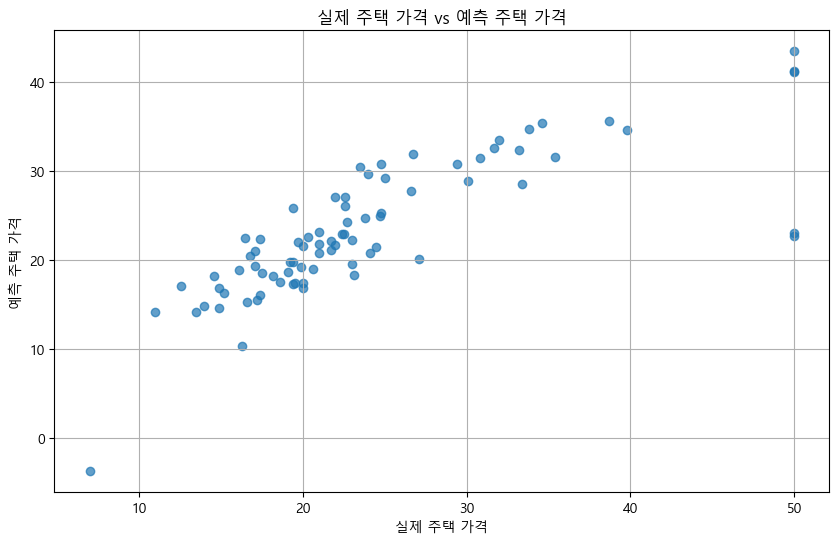

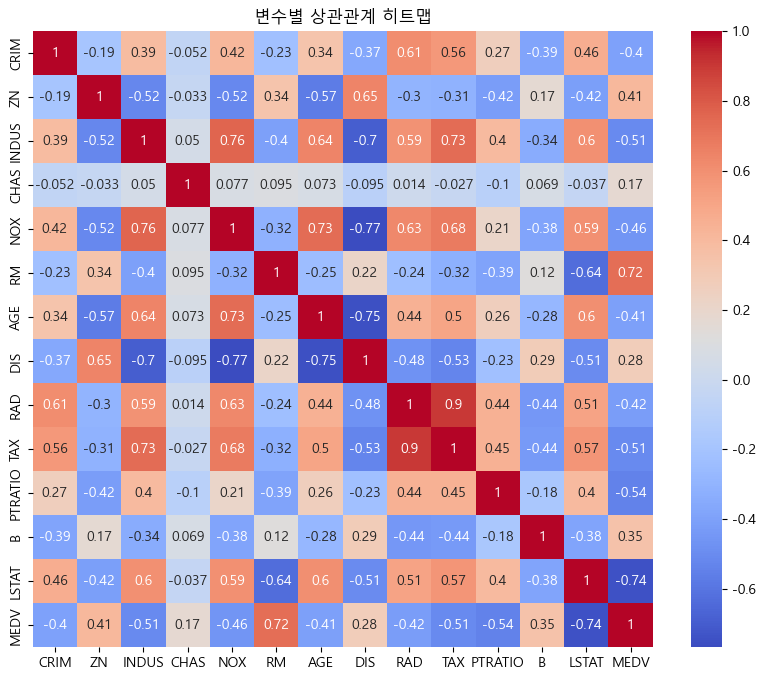

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

In [ ]:
### 컬럼 설명 ###
# CRIM(타운별 1인당 범죄율), ZN(25,000평방피트 주택이 차지하는 비율), INDUS(비소매 상업지역 면적비율)
# CHAS(찰스강 인접 여부), NOX(일산화질소 농도), RM(주택 1가구당 평균 방 개수), AGE(1940년대 이전 주택 비율)
# DIS(보스턴 고용 센터까지의 가중거리), RAD(고속도로 접근성 지수), TAX(10,000달러당 재산세율), PTRATIO(타운별 학생교사 비율)
# B(타운별 흑인인구 비율 계산식), LSTAT(하위 계층의 비율), MEDV(주택의 중간 가격)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 폰트지정
plt.rcParams['font.family'] = 'Malgun Gothic'

# 마이너스 부호 꺠짐 지정
plt.rcParams['axes.unicode_minus'] = False

# 숫자가 지수표현식으로 나올 때 지정
pd.options.display.float_format = '{:.2f}'.format

# 1. 데이터 로드
data = pd.read_csv('dataset/HousingData.csv')

# 2. 데이터 정보 확인
data.head()

data.info()
# 3. 결측값 확인 및 처리
print(data.isnull().sum())

data = data.dropna()

# 3. 결측값 제확인
print(data.isnull().sum())

# 4. 주요 변수 선택
X = data.drop('MEDV', axis=1)
y = data['MEDV']

# 5. 데이터 분할 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 6. 모델 생성 및 학습
model = LinearRegression()
model.fit(X_train, y_train)

# 7. 모델 평가
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'MSE: {mse:.2f}')
print(f'R2 Score: {r2:.4f}')


# 회귀 계수 출력
print('회귀 계수 : ', model.coef_)
print('절편 : ', model.intercept_)

# 결과 시각화
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.xlabel('실제 주택 가격')
plt.ylabel('예측 주택 가격')
plt.title('실제 주택 가격 vs 예측 주택 가격')
plt.grid()
plt.show()


# 변수별 상관관계 히트맵
plt.figure(figsize=(10, 8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.title('변수별 상관관계 히트맵')
plt.show()



랜덤 포레스트 - MSE 28.59, R2 0.66
LinearRegression - MSE 36.34, R2 0.57
DecisionTreeRegressor - MSE 27.30, R2 0.68
최적 모델 : DecisionTreeRegressor


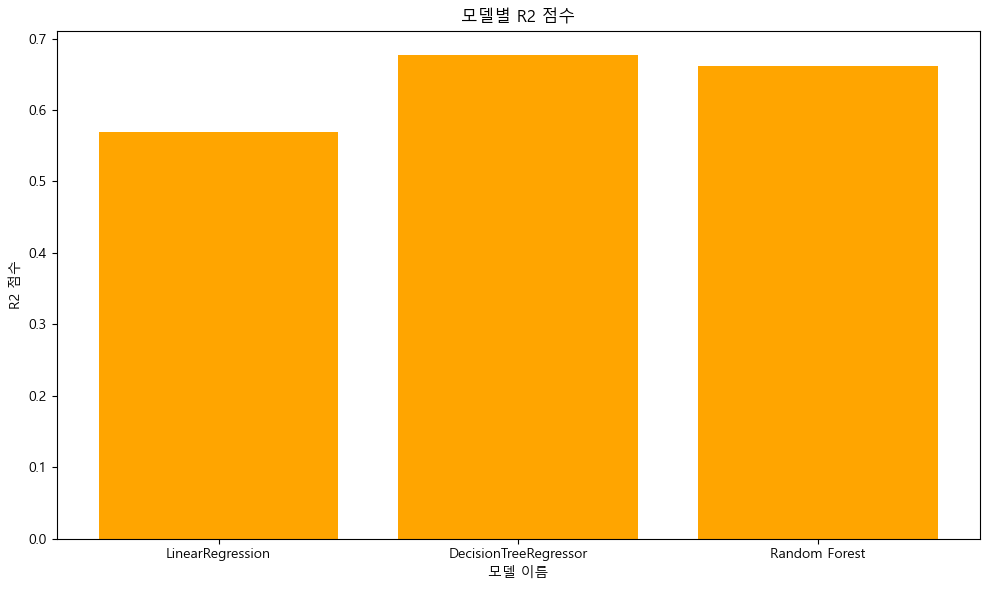

최적 하이퍼파라미터 :  {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 50}
튜닝된 랜덤 포레스트 - MSE 28.63, R2 0.66


In [35]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
import matplotlib.pyplot as plt
import seaborn as sns


# 1. 데이터 로드
data = pd.read_csv('dataset/HousingData.csv')

# 2. 데이터 전처리
data = data.dropna() # 결측값 제거
X = data[['CRIM', 'ZN', 'INDUS','RM', 'AGE', 'DIS', 'TAX', 'LSTAT']]
y = data['MEDV']

# 3. 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4-1. 랜덤 포레스트 모델
rf_model = RandomForestRegressor(n_estimators=100, random_state=42) 
rf_model.fit(X_train, y_train)
rf_y_pred = rf_model.predict(X_test)

# 랜덤 포레스트 평가
rf_mse = mean_squared_error(y_test, rf_y_pred)
rf_r2 = r2_score(y_test, rf_y_pred)
print(f"랜덤 포레스트 - MSE {rf_mse:.2f}, R2 {rf_r2:.2f}")


# 4-2. 다른 모델 비교
models = {
    "LinearRegression" : LinearRegression(),
    "DecisionTreeRegressor" : DecisionTreeRegressor(random_state=42),
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    results[name] = {
        "MSE" : mse,
        "R2" : r2
    }
    print(f"{name} - MSE {mse:.2f}, R2 {r2:.2f}")
    

# 3. 최적 모델 선택 및 시각화
results["Random Forest"] = {"MSE" : rf_mse, "R2" : rf_r2}
# R2를 기준으로 최적 모델 선택
best_model = max(results, key=lambda x: results[x]["R2"])
print(f'최적 모델 : {best_model}')

#결과 시각화
r2_scores = [result["R2"] for result in results.values()]
model_names = list(results.keys())
model_names

plt.figure(figsize=(10, 6))
plt.bar(model_names, r2_scores, color="orange")
plt.xlabel('모델 이름')
plt.ylabel('R2 점수')
plt.title('모델별 R2 점수')
plt.tight_layout()
plt.show()

# 4-3. 랜덤 포레스트 하이퍼파라미터 튜닝
param_grid = {
    'n_estimators' : [50, 100, 200],
    'max_depth' : [None, 10, 20],
    'min_samples_split' : [2, 5, 10],
}

grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring='r2')
grid_search.fit(X_train, y_train)

print('최적 하이퍼파라미터 : ', grid_search.best_params_)
best_rt_model = grid_search.best_estimator_
tuned_rt_y_pred = best_rt_model.predict(X_test)

# 튜닝된 모델 평가
tuned_rf_mse = mean_squared_error(y_test, tuned_rt_y_pred)
tuned_rf_r2 = r2_score(y_test, tuned_rt_y_pred)
print(f"튜닝된 랜덤 포레스트 - MSE {tuned_rf_mse:.2f}, R2 {tuned_rf_r2:.2f}")



